# Overview

This fine-mapping tutorial was developed using simulated data shipped with [`susieR`](https://github.com/stephenslab/susieR) package.
The simulated data contains simulated phenotype matrix $Y$ in $N \approx 600$ individuals. 
The goal is to identify from the genotype matrix $X_{N\times P}$ ($P=1000$) the genetic variables that directly cause changes in the phenotypic values.

**There are several questions throughout the notebook, and please answer each of them by adding cells (in Markdown or R) under the question and keep the code you use there as well.**

The simulated data-set is [available
here](https://github.com/stephenslab/susieR/blob/master/data/N3finemapping.RData),
as part of the `susieR` package. In this tutorial we will first explore the data with conventional univariate association analysis,
then perform preliminary fine-mapping analysis under simplified 
assumptions to illustrate the idea of statistical fine-mapping, and finally use the R package `susieR` to perform formal Bayesian fine-mapping analysis.
We will also discuss fine-mapping using association summary statistics.

# Explore the association data-set

First let's install the package `susieR` according to [its Github repo](https://github.com/stephenslab/susieR) and `corrplot` to draw some plots later. This may take a while.

In [2]:
install.packages("susieR")
install.packages("corrplot")

Installing package into 'C:/Users/Wayne Monical/Documents/R/win-library/4.1'
(as 'lib' is unspecified)

also installing the dependencies 'irlba', 'mixsqp', 'reshape'





  There is a binary version available but the source version is later:
       binary source needs_compilation
mixsqp 0.3-48 0.3-54              TRUE

  Binaries will be installed
package 'irlba' successfully unpacked and MD5 sums checked
package 'mixsqp' successfully unpacked and MD5 sums checked
package 'reshape' successfully unpacked and MD5 sums checked
package 'susieR' successfully unpacked and MD5 sums checked

The downloaded binary packages are in
	C:\Users\Wayne Monical\AppData\Local\Temp\RtmpohQ11O\downloaded_packages


Installing package into 'C:/Users/Wayne Monical/Documents/R/win-library/4.1'
(as 'lib' is unspecified)




  There is a binary version available but the source version is later:
         binary source needs_compilation
corrplot   0.92   0.95             FALSE



installing the source package 'corrplot'




Please execute the following code cell to load the simulated data.

In [2]:
rm(list=ls())
library(susieR)
library(corrplot)
data(N3finemapping)
attach(N3finemapping)

Warning message:
"package 'susieR' was built under R version 4.1.3"
corrplot 0.95 loaded



In [3]:
ls()

[1] "N3finemapping"

The loaded dataset, `N3finemapping`, contains regression data $X$ and $Y$, 
along with some other relevant attributes in the context of genetic studies. It also
contains the "true" regression coefficients the data is simulated from.

In [4]:
names(N3finemapping)

[1] "X"                 "chrom"             "pos"              
[4] "true_coef"         "residual_variance" "Y"                
[7] "allele_freq"       "V"

In [5]:
dim(X)
head(X)

[1]  574 1001

-0.02090592,0.4738676,0.1620209,-0.05226481,-0.1637631,-0.026472457,0.1689895,-0.2421603,0.1585366,-0.1567944,...,-0.4006969,-1.09254036,-0.4119346,-0.2857143,-0.3885017,-0.3919861,-0.3969795,-0.02090592,-0.2844549,-0.3883308
-0.02090592,-0.5261324,1.1620209,-0.05226481,-0.1637631,0.006059281,1.1689895,-0.2421603,1.1585366,-0.1567944,...,-0.4006969,-1.09254036,-0.4119346,-0.2857143,-0.3885017,-0.3919861,-0.3969795,-0.02090592,-0.2844549,-0.3883308
-0.02090592,-0.5261324,1.1620209,-0.05226481,-0.1637631,-0.026472457,1.1689895,-0.2421603,1.1585366,-0.1567944,...,0.5993031,-0.09254036,0.5880654,-0.2857143,-0.3885017,-0.3919861,0.6030205,-0.02090592,-0.2844549,-0.3883308
-0.02090592,0.4738676,0.1620209,-0.05226481,-0.1637631,-0.026472457,0.1689895,-0.2421603,0.1585366,-0.1567944,...,-0.4006969,-1.09254036,-0.4119346,-0.2857143,-0.3885017,-0.3919861,-0.3969795,-0.02090592,-0.2844549,-0.3883308
-0.02090592,-0.5261324,1.1620209,-0.05226481,-0.1637631,-0.026472457,1.1689895,-0.2421603,1.1585366,-0.1567944,...,-0.4006969,-1.09254036,-0.4119346,-0.2857143,-0.3885017,-0.3919861,-0.3969795,-0.02090592,-0.2844549,-0.3883308
-0.02090592,-0.5261324,0.1620209,-0.05226481,-0.1637631,-0.026472457,0.1689895,0.7578397,0.1585366,-0.1567944,...,-0.4006969,-1.09254036,-0.4119346,-0.2857143,-0.3885017,-0.3919861,-0.3969795,-0.02090592,-0.2844549,-0.3883308


-----------------------------------------

**Example question: in the genotype matrix `X`, how many individuals and the genetic variants are included? What is the genotype value for the 100th variant of the 21st individual?**

**Example answer:** The genotype matrix has 574 individuals and 1001 genetic variants. The genotype value for the 100th variant of the 21st individual is 0.4408.

In [6]:
dim(X)

[1]  574 1001

In [7]:
X[21, 100]

[1] 0.4407666

-----------------------------------------

The phenotype matrix contains values for the 574 individuals for 2 traits,

In [24]:
dim(Y)

[1] 574   2

We focus on the first trait, let

In [25]:
y = Y[,1]
b = true_coef[,1]

There are 3 "causal" variants for this trait,

In [26]:
which(b != 0)

[1] 403 653 773

Note: in this tutorial we will avoid the phrase "causal", and use "effect variable" to refer to the variants having true non-zero effects on the phenotype.

-----------------------------------------

**Question 1: Please use R function `plot` to visualize the true effects vector. What are the effect sizes for these 3 "causal" variants?**

**Answer:** The three effect sizes for the three causal varaints (the variants with non-zero effect size) are -0.83179, 1.18917, and 1.39929.

In [22]:
round(true_coef[c(403, 653, 773),1], 5)

[1]  1.18917 -0.83179  1.39929

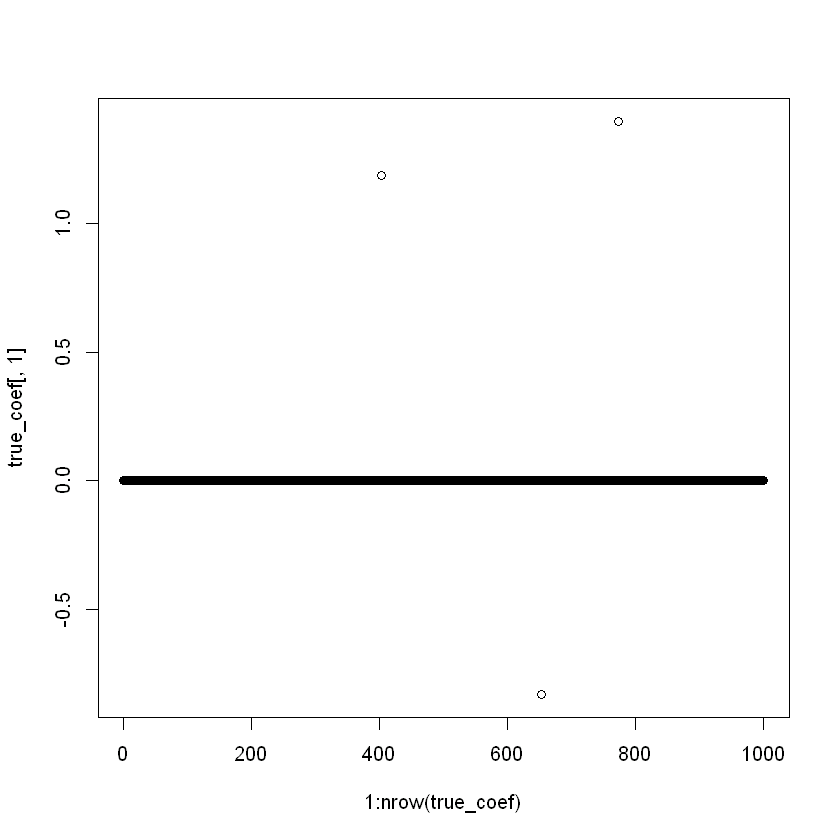

In [15]:
plot(x = 1:nrow(true_coef), y = true_coef[,1])

-----------------------------------------

# Association testing via simple linear regression

`univariate_regression` function in `susieR` can be used to perform association testing 
by fitting univariate simple regression for each variable separately.
The results are $\hat{\beta}$ for effect size estimates, and their standard errors $SE(\hat{\beta})$.

In [27]:
sumstats <- univariate_regression(X, y)

-----------------------------------------

**Question 2: Please use R function plot to compare the true effects variable `b` with the estimated effect sizes `sumstats$betahat`. Are they consistent, and why?**

**Answer:** The true effects variable and the estimated effect sizes are fairly consistent where the true betas are non-zero (ids 403, 653, and 773), because for a single test, linear regression is robust. In other words, if there is a true effect, linear regression will find it. However, the beta hat estimates are not consistent for all other effects (where the true betas are equal to zero). This is because linear regression is not robust to multiple comparisons. Here we are fitting 1001 models with the univariate regression method, so many of the beta hats will be large by random chance, even if the true effect size is zero. 

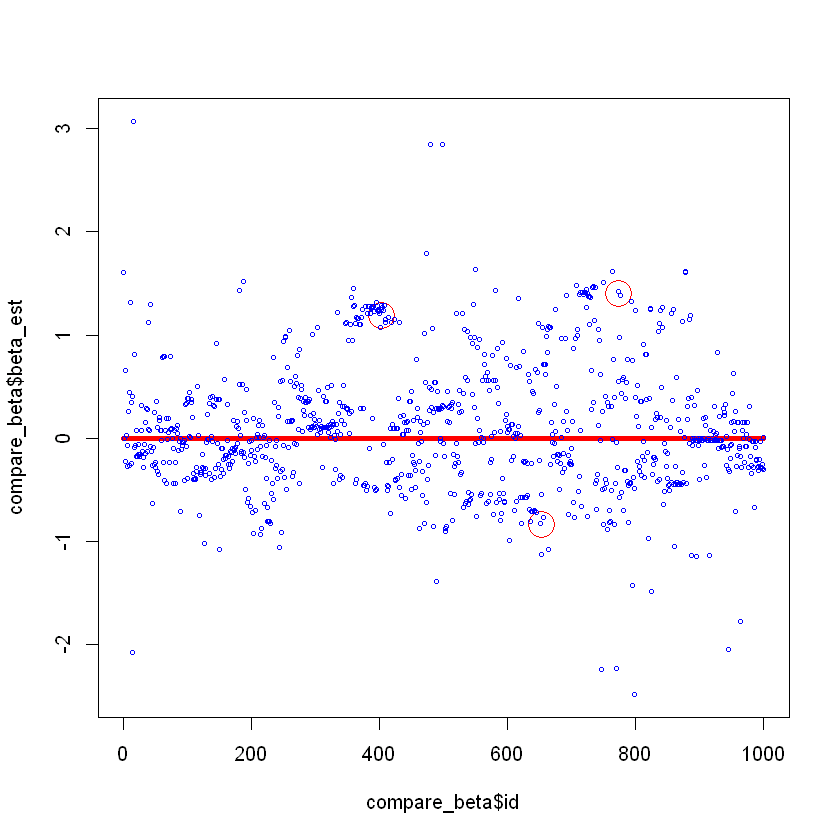

In [46]:
# comparing for all variants
compare_beta = 
   rbind(
       data.frame(id = 1:length(b), beta_est = b, color = "red", size = 0.5 + 2.5 * (b != 0)),
       data.frame(id = 1:length(b), beta_est = sumstats$betahat, color = "blue", size = 0.5))

plot(compare_beta$id, compare_beta$beta_est, col = compare_beta$color, cex = compare_beta$size)

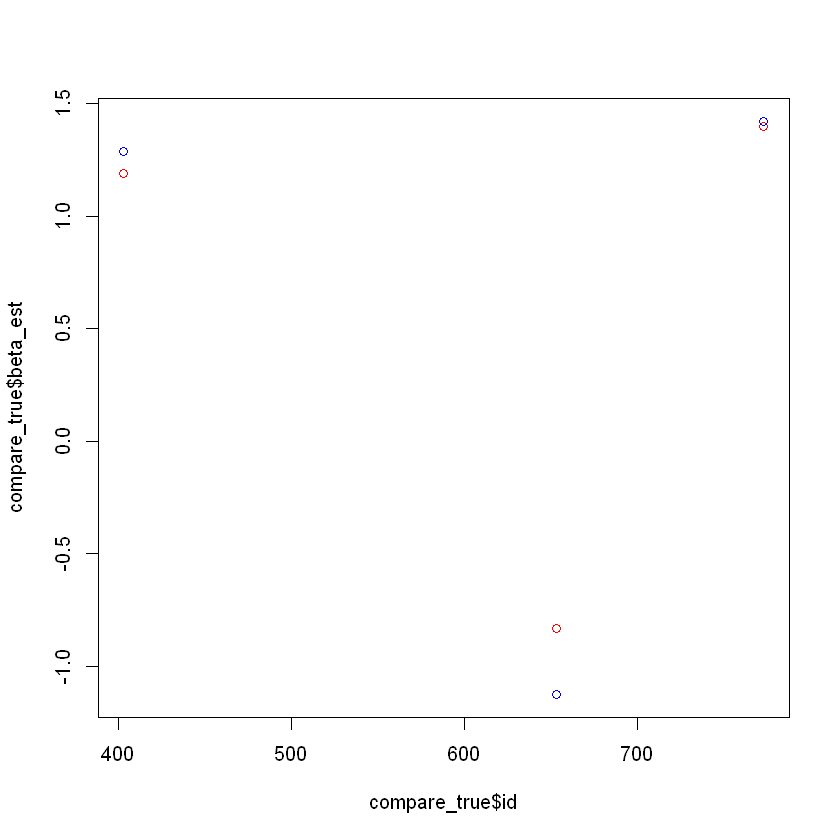

In [47]:
# comparing estimates for the true effect
compare_true = compare_beta[compare_beta$id %in% c(403, 653, 773),]
plot(compare_true$id, compare_true$beta_est, col = compare_true$color)

-----------------------------------------

z-scores can be derived from these quantities; $-log_{10}$ p-values can then becomputed from z-scores, 

In [48]:
z_scores <- sumstats$betahat / sumstats$sebetahat
log10p <- -log10(pchisq(z_scores^2,1,lower.tail=F))

-----------------------------------------

**Question 3: How many variables have p-values smaller than $5 \times 10^{-8}$? How would you interpret those variants based on the univariate association analysis?**


**Answer:** There are eight variables with a p-value smaller than 5e-8. Based on the univariate analysis, I would interpret these variables as having a non-zero true effect on the response variable. The true effects of variable 653 and 773 are present, but notable, the true effect of variable 403 is missing. 

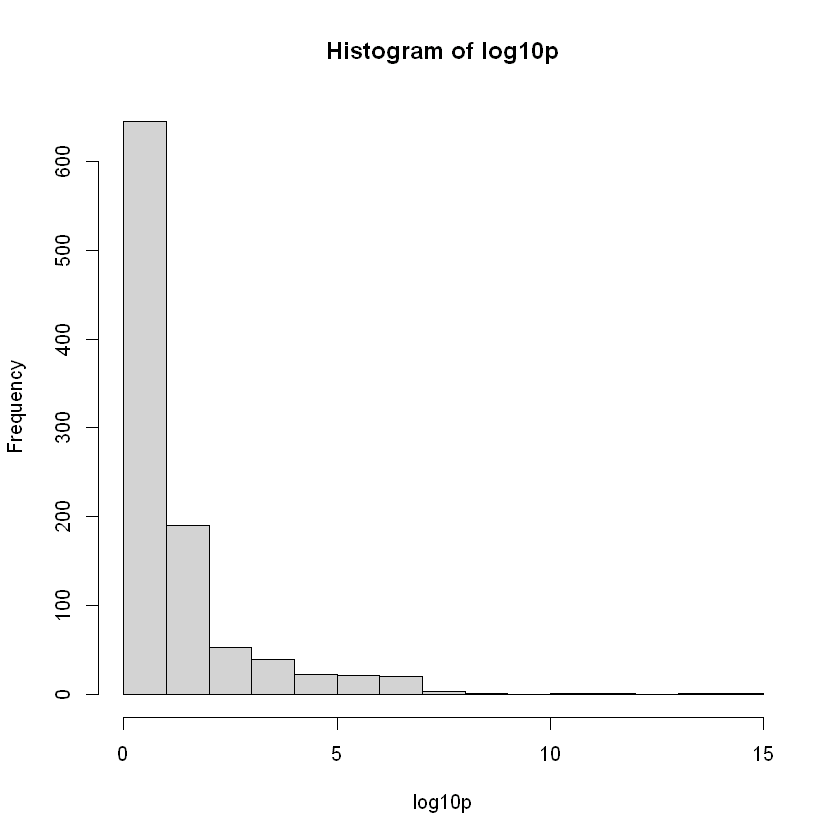

In [63]:
hist(log10p)

In [64]:
sum(log10p > -log10(5 * 10^(-8)))

[1] 8

In [68]:
sig_beta_hats = which(log10p > -log10(5 * 10^(-8)))
sig_beta_hats

[1] 653 666 667 773 776 777 794 800

**Question 4: What's the correlation between these variables (with p-values smaller than $5 \times 10^{-8}$) in the original genotype data `X`? Draw a correlogram and print out the pair with highest positive correlation. What does it mean for those two variants?**

**Answer:** The highest correlation is between variables 773 and 777 with a value of 0.981573. These variables are nearly identical. Since 773 is a true effect, and therefore is highly significant, it is no surprise that the highly correlated variable 777, is also found to be highly significant. 

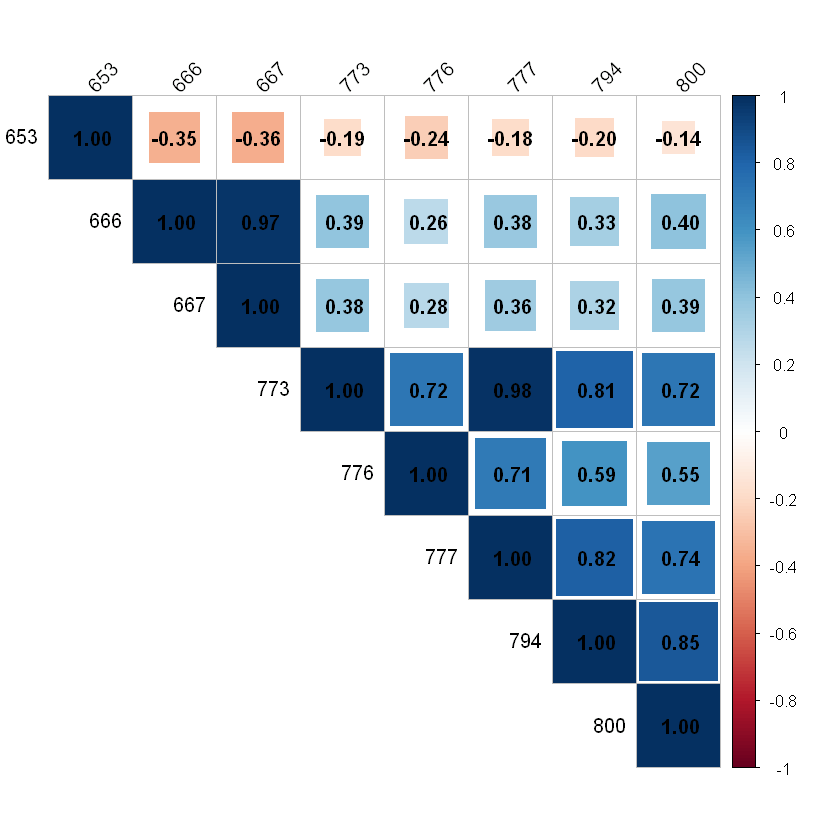

In [84]:
library(corrplot) 

sig_X = X[,sig_beta_hats]
names(sig_X) = sig_beta_hats

cor_matrix = cor(sig_X) 
colnames(cor_matrix) <- sig_beta_hats
rownames(cor_matrix) <- sig_beta_hats
  
# Create the correlogram 
corrplot(cor_matrix, type = "upper",  
         method = "square",  
         addCoef.col = "black",  
         tl.col = "black", tl.srt = 45)

In [89]:
print(paste0('Highest Correlation: ', round(cor_matrix['773', '777'], 6) ))

[1] "Highest Correlation: 0.981573"


-----------------------------------------

`susieR` package provides a plot function to generate Manhattan plot for the association test results. Notice that the true effect variables are labelled in red (true effects provided to `susie_plot` via setting `b=` parameter),

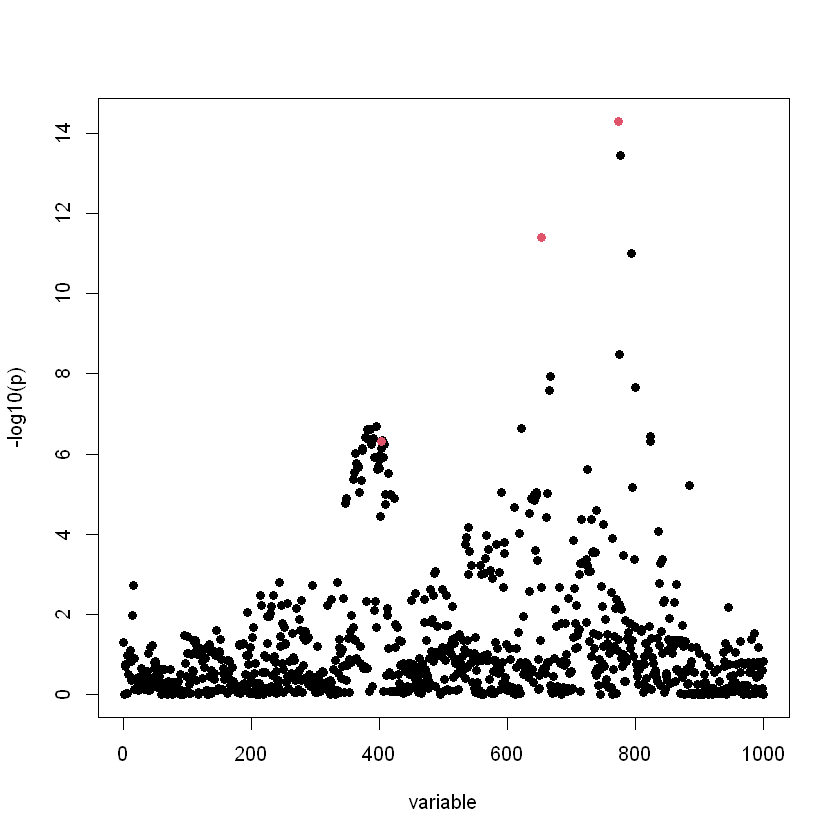

In [90]:
susie_plot(z_scores,y="z",b=b)

As shown on this plot, the "lead" SNP (the one with smallest p-value) is indeed one of the true effect variables. However, the 2nd most significant SNP is not one of the other two effect variables, and there are many other SNPs having p-values smaller than $5 \times 10^{-8}$, a widely accepted significant level threshold for genetic association studies.

-----------------------------------------

**Question 5: What index is the second most significant SNP? Is it one of the other two true effect variables? What would you say about the relationship between the top and 2nd most significant SNPs?**


**Answer:** The second most significant SNP is 777, which is not one of the other two true effect variables. 777 is the SNP that is most correlated with the true effect of SNP 773. 

In [97]:
names(z_scores) = 1:length(z_scores)
head(order(-(abs(z_scores))))

[1] 773 777 653 794 776 667

-----------------------------------------

# "One causal variant" assumption for fine-mapping

Under the assumption that there is only one true effect in the region of interest, fine-mapping does not have to use linkage disequilibrium (LD) information between variables. It can be performed by simply calculating the likelihood of the association model for each variable separately, then computing the probability for a variable being the true effect as the ratio of its likelihood over the sum of likelihoods over all variables. We use linear regression `lm` in R to compute the log-likelihood,

In [98]:
lliks = sapply(1:ncol(X), function(i) logLik(lm(y~X[,i])))

Then compute the probability for each variable being the true effect variable: 

In [100]:
lliks = lliks - max(lliks) # To avoid taking exp on large numbers in the next line, thus improving numerical stability 
probs = exp(lliks)/sum(exp(lliks))

We use `susie_plot` function to plot these probabilities computed, and color label the true effect variables:

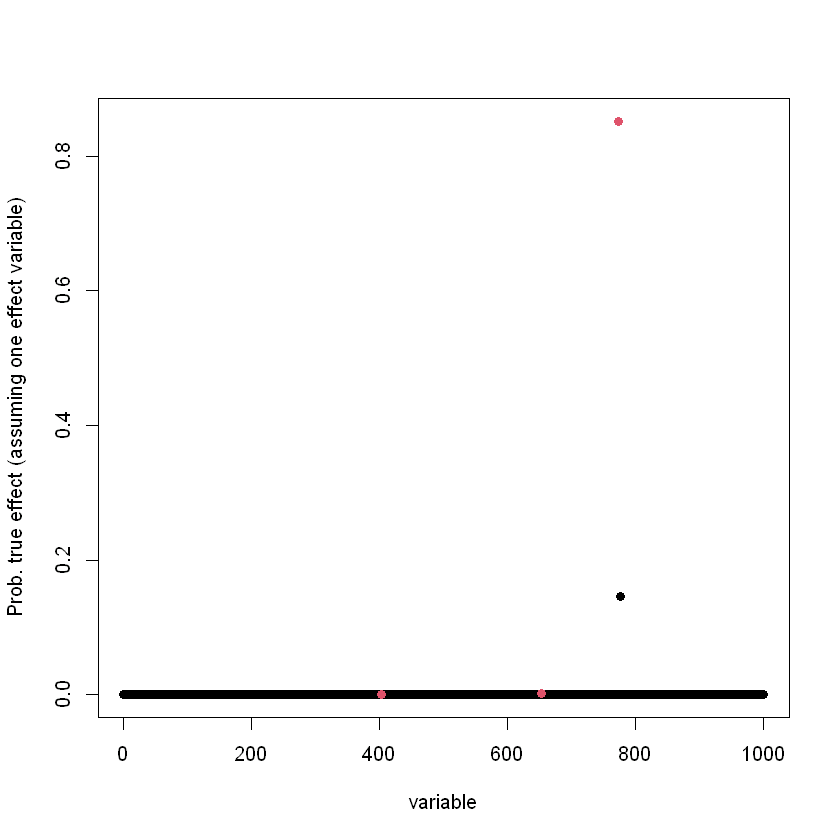

In [101]:
susie_plot(probs, y="PIP", b=b, ylab = "Prob. true effect (assuming one effect variable)")

As expected, under the "one causal variant" assumption, only the lead SNP is identified with over 80% probability of having a non-zero effect. The other two true effect variables in red are not identified.

## 95% credible set for single effect

95% credible set (CS) is defined as a set of variables with 95% probability of containing a true effect. By visually examine the plot above, we can see that the lead SNP has over 80% probability being the true effect, and another SNP near it has almost 20% probability of being the true effect. The 95% credible set should thus contain both of them in order for the coverage to exceed 95%. Indeed, we can formally verify this using an internal function `in_CS` to assess if a variable is in a single effect CS. We report the indices of these variables,

In [102]:
which(susieR:::in_CS(t(probs), coverage = 0.95) != 0)

[1] 773 777

These variables indeed correspond to the two non-zero probability variables on the plot above.

# Fine-mapping with individual level data using Sum of Single Effects model

When multiple true effects are expected, formal statistical fine-mapping via Bayesian Variable Selection
should be performed. We fit a Sum of Single Effects (SuSiE) model implemented in `susieR` package, 
assuming at most 10 causal variables (although SuSiE is robust to the choice of `L`).

In [103]:
fitted <- susie(X, y, L = 10)

HINT: For an X with many columns, please consider installingthe Rfast package for more efficient credible set (CS)calculations.



## 95% credible sets for each single effect

By default, `susie` function computes 95% CS each containing one effect variable,

In [104]:
print(fitted$sets)

$cs
$cs$L2
[1] 653

$cs$L1
[1] 773 777

$cs$L3
 [1] 362 365 372 373 374 379 381 383 384 386 387 388 389 391 392 396 397 398 399
[20] 400 401 403 404 405 407 408 415


$purity
   min.abs.corr mean.abs.corr median.abs.corr
L2    1.0000000     1.0000000       1.0000000
L1    0.9815726     0.9815726       0.9815726
L3    0.8686309     0.9640176       0.9720711

$cs_index
[1] 2 1 3

$coverage
[1] 0.9998236 0.9988858 0.9539811

$requested_coverage
[1] 0.95



The 3 true signals have been captured by the 3 CS reported here. The
3rd CS contains many variables, including the true causal variable
`403`. The minimum absolute correlation is 0.86.

-----------------------------------

**Question 6: Print the credible sets if we use 99% as the coverage. Hint: you may want to check the source code for `susie` function from [here](https://github.com/stephenslab/susieR)**.

**Answer:** By adjusting the `coverage` argument in the `susie` function, we can set the model to create credible sets for 99% coverage instead of 95%. The first two credible sets are unchanged, but the third adds several SNPs for larger coverage. It still has the true effect SNP 403. 

In [106]:
fitted99 <- susie(X, y, L = 10, coverage = 0.99)

HINT: For an X with many columns, please consider installingthe Rfast package for more efficient credible set (CS)calculations.



In [108]:
print(fitted99$sets)

$cs
$cs$L2
[1] 653

$cs$L1
[1] 773 777

$cs$L3
 [1] 360 361 362 365 366 367 368 372 373 374 379 381 383 384 386 387 388 389 391
[20] 392 396 397 398 399 400 401 403 404 405 407 408 409 410 415 419


$purity
   min.abs.corr mean.abs.corr median.abs.corr
L2    1.0000000     1.0000000       1.0000000
L1    0.9815726     0.9815726       0.9815726
L3    0.8310851     0.9499450       0.9556871

$cs_index
[1] 2 1 3

$coverage
[1] 0.9998236 0.9988858 0.9906629

$requested_coverage
[1] 0.99



**Question 7: does higher coverage mean you have larger CS, or smaller CS? Why is that? Please look at the 3rd CS as an example in the two fitted results, and explain why the minimum absolute correlation is lower when the coverage is higher?**

**Answer:** Higher coverage means that you will have a larger credible set. It is analagous to having a higher confidence interval for continuous values. High confidence means that you must allow for a strictly wider set of possibilities. In this case, the wider set of possibilities means allowing for more possible SNPs that may be the true effect. The minimum absolute correlation is the boundary for inclusion into the credible set. Lowering this value allows SNPs with lower correlation into the credible set, therefore widening the field of possibilities.

-----------------------------------

## Posterior inclusion probabilities

Here we summarize the fine-mapping results by posterior inclusion
probability (PIP):

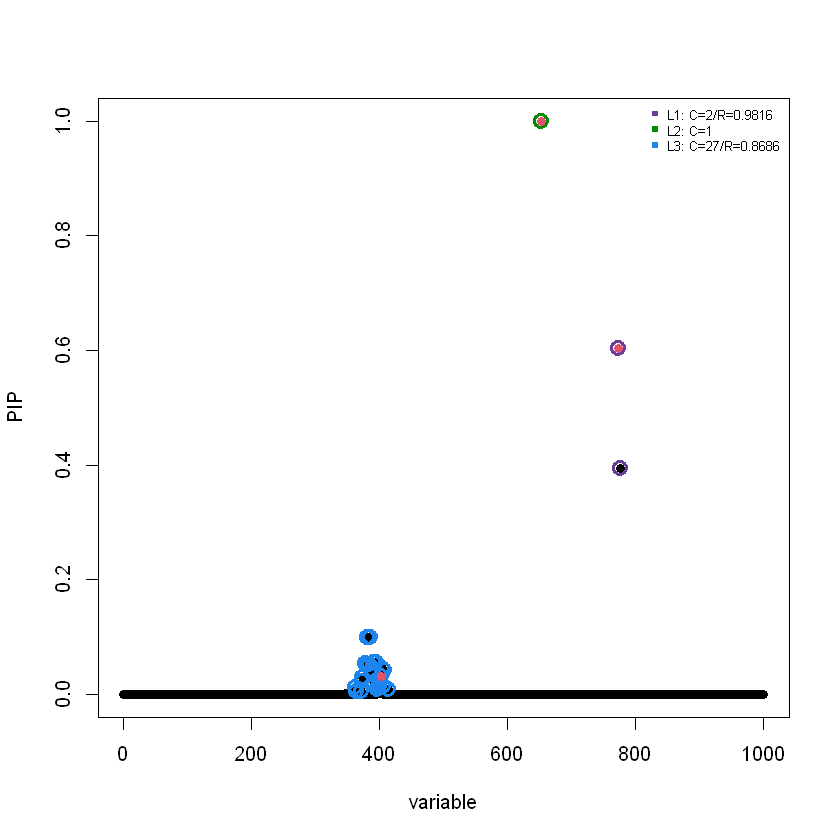

In [110]:
susie_plot(fitted, y="PIP", b=b, add_legend=T)

The true effect variables are colored red, and the three 95% CS identified are
circled in different colors. 

-------------------------------------------

**Question 8: Recall the true effect variables we know before running any susie, and for the variable 403, what is the PIP? What's the average PIP of the 3rd CS? Is the PIP for variable 403 higher or lower than the average, and why is that?**

Hint: You can use the code below to compare $-log_{10}$ p-value and PIP for the CS containing variable 403:

```R
    i  <- fitted$sets$cs$L3
    z3 <- cbind(i,log10p[i],fitted$pip[i])
    colnames(z3) <- c('position', '-log10 pvalue', 'PIP')
    z3[order(z3[,2], decreasing = TRUE),]
```

In [ ]:
i  <- fitted$sets$cs$L3
z3 <- cbind(i,log10p[i],fitted$pip[i])a
colnames(z3) <- c('position', '-log10 pvalue', 'PIP')

**Answer:** The posterior inclusion probability of variable 403 is 0.0319928, which is less than the average PIP of the third credible set, 0.0353326. Graphing the negative log p-value against the PIP, we see a positive approximately linear relationship. Variant 403 lies close to this line. Though it is in truth a causal variant, its p value has nothing to distinguish it from the other variants in the credible set. 

In [118]:
# look at the 403's PIP
z3[z3[,'position'] == 403, ]

position -log10 pvalue           PIP 
 403.00000000    6.32286136    0.03199285

In [119]:
# get the mean PIP
mean(z3[,'PIP'])

[1] 0.03533265

In [141]:
mean(z3[z3[,'position'] != 386,'PIP'])

[1] 0.03283159

integer(0)

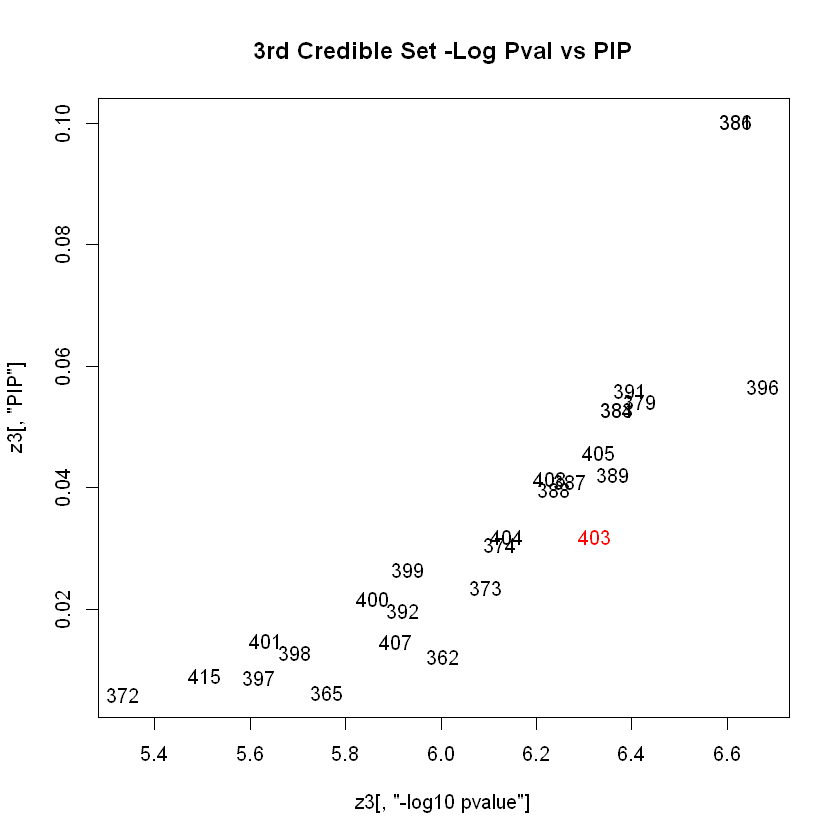

In [140]:
color_map = c('black', 'red')[(col = z3[,'position'] == 403) + 1]
plot(z3[,'-log10 pvalue'],z3[, 'PIP'], col = 'white') + 
text(z3[,'-log10 pvalue'],z3[, 'PIP'], col = color_map, labels =  z3[,'position']) + 
title(main = '3rd Credible Set -Log Pval vs PIP') 

integer(0)

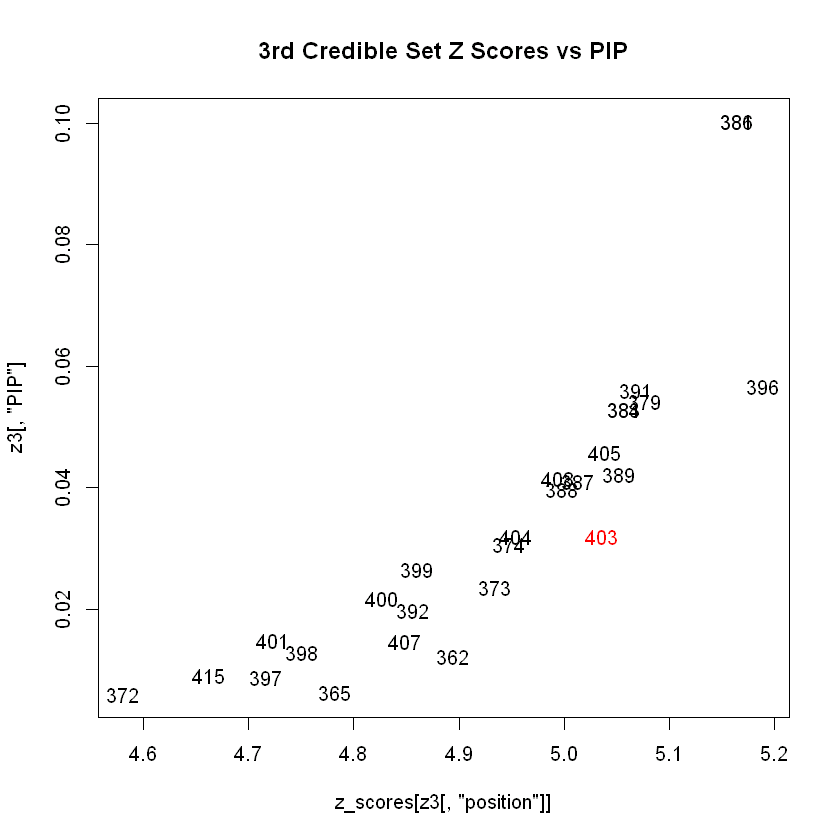

In [149]:
plot(z_scores[z3[,'position']],z3[, 'PIP'], col = 'white') + 
text(z_scores[z3[,'position']],z3[, 'PIP'], col = color_map, labels =  z3[,'position']) + 
title(main = '3rd Credible Set Z Scores vs PIP') 

***

**Question 9: Please rerun the `susie` analysis setting `L=1` to detect a maximum of only one effect across the region. How does the result compare to the previous section of "one causal effect" fine-mapping using likelihoods from univariate analysis?**

**Answer:** The resulting credible set of 773 and 777 are the same in each method. Since we have specified to the SUSIE method that there can be at most one effect `L = 1`, both methods attempted to find a credible set for one effect. 

-------------------------------------------

## Choice of prior effect size

In SuSiE, the prior effect size is parameterized by the percentage of variance explained by a variable, $h_j^2$. 
By default, SuSiE estimates $h_j^2$ and uses it as the prior (an empirical Bayes approach). 
Here we demonstrate fixing the prior effect size to 0.2, i.e., we believe a non-zero effect variable can explain 20% variation in quantitative trait values:

HINT: For an X with many columns, please consider installingthe Rfast package for more efficient credible set (CS)calculations.



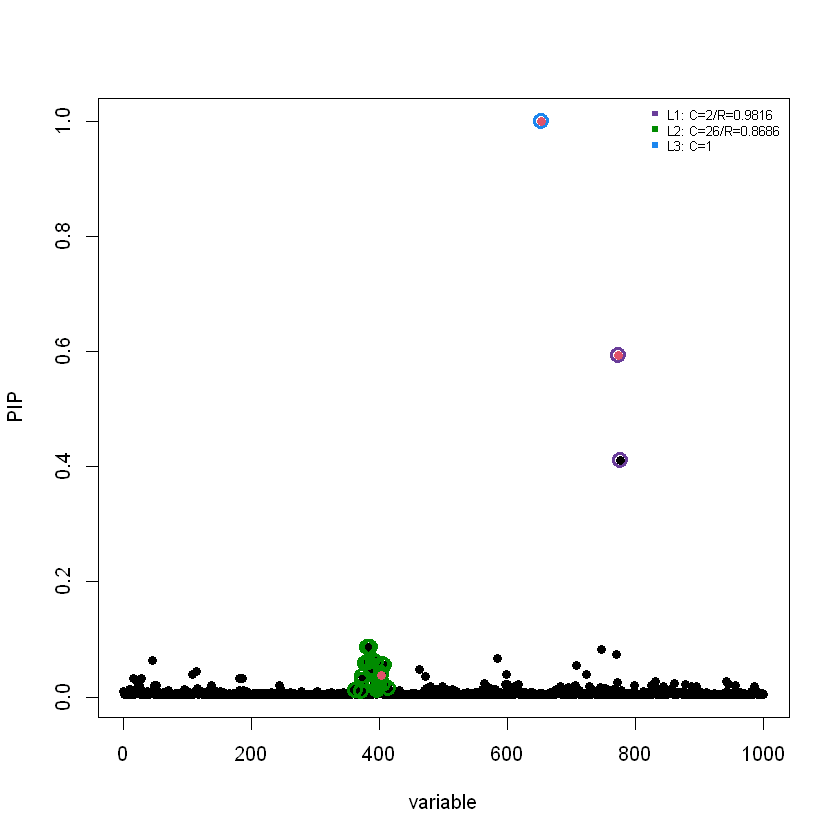

In [152]:
fitted2 = susie(X, y, L = 10, estimate_prior_variance = FALSE, scaled_prior_variance = 0.2)
susie_plot(fitted2, y='PIP', b=b, add_legend=T)

The result is very similar to when prior effects are estimated. 

-------------------------------------------

**Question 10: Please change `scaled_prior_variance` to different numbers between 0 and 1, and examine the results. What happens if you set it to 0.001, and why?**

**Answer:** Setting the `scaled_prior_variance` to 0.001 causes the SuSiE method to not find any credible sets with 95% coverage. Reading about this parameter, I have found that lowering it primes the SuSiE model to expect weak signals from the causal variants, favoring small and precise credible sets, sacrificing sensitivity. In this case, the model was not sensitive enough to detect any credible sets.  

-------------------------------------------

# Fine-mapping with summary statistics via `susie_rss`

Summary statistics of genetic association studies typically contain effect size ($\hat{\beta}$ coefficient from regression), p-value and minor allele frequencies. 
These information can be used to perform fine-mapping with given an additional input of correlation matrix between variables.
The correlation matrix in genetics is typically referred to as LD matrix (LD for linkage disequilibrium). 
One may use external reference panels to estimate it when this matrix cannot be obtained from samples directly. There is a potential problem using LD from reference panel, and we demonstrated it in the next section.
Caution that LD matrix here has to be correlation matrix $r$, not $r^2$ or $|r|$.

We have previously computed z-scores for this data-set. The correlation matrix can be computed directly from $X$ matrix, 

In [164]:
R <- cor(X)

SuSiE regression with summary statistics is implemented as `susie_rss` function, 

In [166]:
fitted_rss <- susie_rss(z_scores, R, L = 10)


HINT: For large R or large XtX, consider installing the Rfast package for better performance.



We compare the PIP obtained with previous analysis using individual level data,

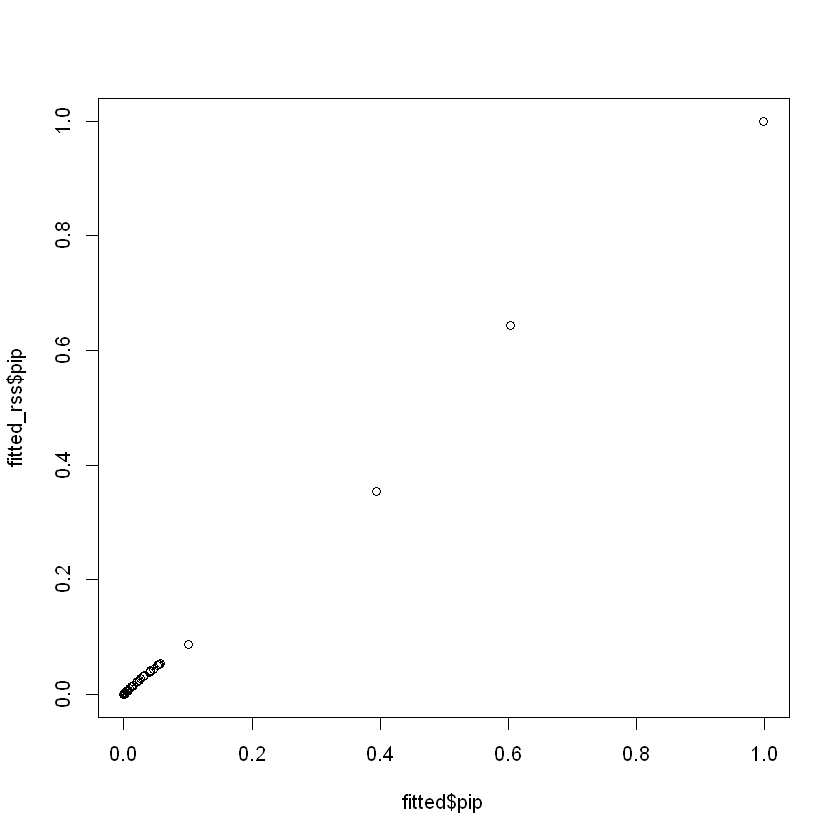

In [167]:
plot(fitted$pip, fitted_rss$pip, ylim=c(0,1))

The results very much agree. This is expected when the summary statistics are indeed derived from the individual level data.

## Use LD from external reference data

When original genotype information is not available, 
one may use reference panel to estimate LD matrix. 
False discoveries may occur if the LD pattern from the reference panel does not agree well with the original sample. 

To illustrate, we randomly generated 500 samples from $N(0,R)$ and treated them as reference panel genotype matrix `X_ref`.

In [168]:
set.seed(1234)
tmp = matrix(rnorm(500*1001), 500, 1001)
eigenR = eigen(R)
eigenR$values[eigenR$values < 1e-10] = 0
X_ref = tmp %*% (eigenR$values * t(eigenR$vectors))
R_ref = cor(X_ref)

Using `susie_rss` function with LD from reference panel,


HINT: For large R or large XtX, consider installing the Rfast package for better performance.



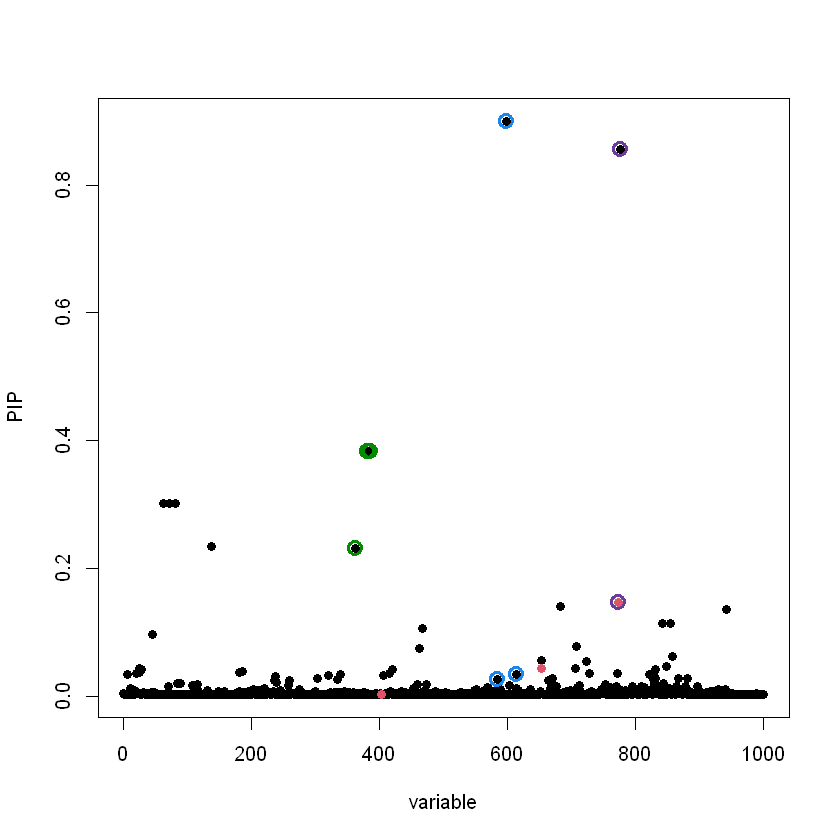

In [169]:
fitted_rss_ref <- susie_rss(z_scores, R_ref, L = 10)
susie_plot(fitted_rss_ref, y="PIP", b=b)

-------------------------------------------

**Question 11: Please compare and comment on the CS reported using reference LD panel versus using the correct LD computed from genotype data. Are there any false discoveries?**

**Answer:** Yes, credible sets two and three contain no true effects, and the true effect variables 403 and 653 were not in any credible set. 

-------------------------------------------

We recommend the following modification to the LD matrix when reference panel ($R_{ref}$) are used,
$$
\tilde{R} = \text{cov2cor}((1-w)R_{ref}+ w zz^\intercal)),
$$
where z is the original summary statistics. We suggest using $w = 1/n_{ref}$, $n_{ref}$ is the sample size from the reference panel. The modified LD matrix becomes
$$
\tilde{R} = \text{cov2cor}(\frac{n_{ref}-1}{n_{ref}}R_{ref}+ \frac{1}{n_{ref}} zz^\intercal)) = \text{cov2cor}(\frac{1}{n_{ref}}(X_{ref}^\intercal X_{ref}+ zz^\intercal)),
$$
where `X_ref` is column-standardized. This modification is implemented in `susie_rss` with parameter `z_ld_weight`:



HINT: For large R or large XtX, consider installing the Rfast package for better performance.



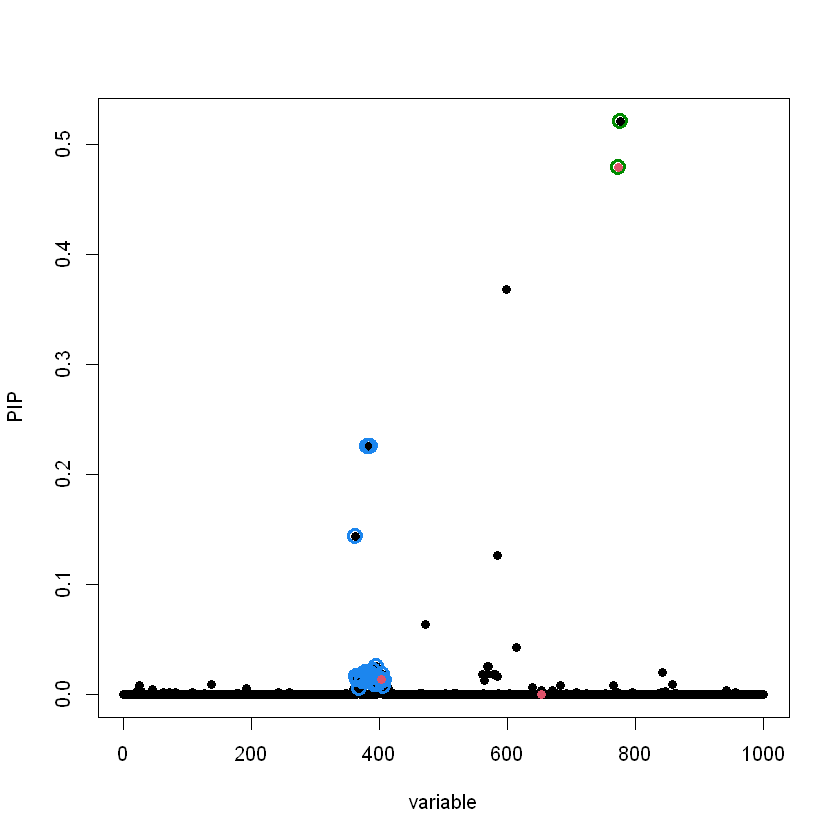

In [174]:
n_ref = 500
fitted_rss_ref_corrected <- susie_rss(z_scores, R_ref, z_ld_weight = 1/n_ref, L = 10)
susie_plot(fitted_rss_ref_corrected, y="PIP", b=b)

***
**Question 12: Please compare and comment on the results using adjusted reference LD panel. Is the result improved?**

**Answer:** Yes, the results significantly improve. There are no false discoveries, and true effect 403 is now included in a credible set. 

***

# Exercise: fine-mapping analysis on a different data-set

Please load and analyze another data-set provided in `susieR` package:

In [176]:
rm(list=ls())
library(susieR)
data(N2finemapping)

Please use the same R code for `N3finemapping` data to analyze this new data-set, similarly focusing on the first column of the phenotype matrix as the phenotype of interest. 
This data-set contains two true effect variables. However, as you are soon to find out in univariate linear regression analysis, **the lead SNP via univariate analysis is neither of the two effect variables**.

-------------------------------------------

**Question 13: please run `susie_rss` on the N2finemapping dataset and report the results below. Does it capture any true effect variant?**

**Answer:**

In [184]:
?univariate_regression

univariate_regression {susieR},R Documentation
X,n by p matrix of regressors.
y,n-vector of response variables.
Z,"Optional n by k matrix of covariates to be included in all regresions. If Z is not NULL, the linear effects of covariates are removed from y first, and the resulting residuals are used in place of y."
center,"If center = TRUE, center X, y and Z."
scale,"If scale = TRUE, scale X, y and Z."
return_residuals,Whether or not to output the residuals if Z is not NULL.


In [183]:

phenotype = N2finemapping$Y[,1]

In [188]:
phenotype = N2finemapping$Y[,1]

n3_univariate <- univariate_regression(X = N2finemapping$X, y = phenotype)

z_scores <- n3_univariate$betahat / n3_univariate$sebetahat

In [189]:
n3_rss = 
    susie_rss(
        z = z_scores,
        R = cor(N2finemapping$X))


HINT: For large R or large XtX, consider installing the Rfast package for better performance.



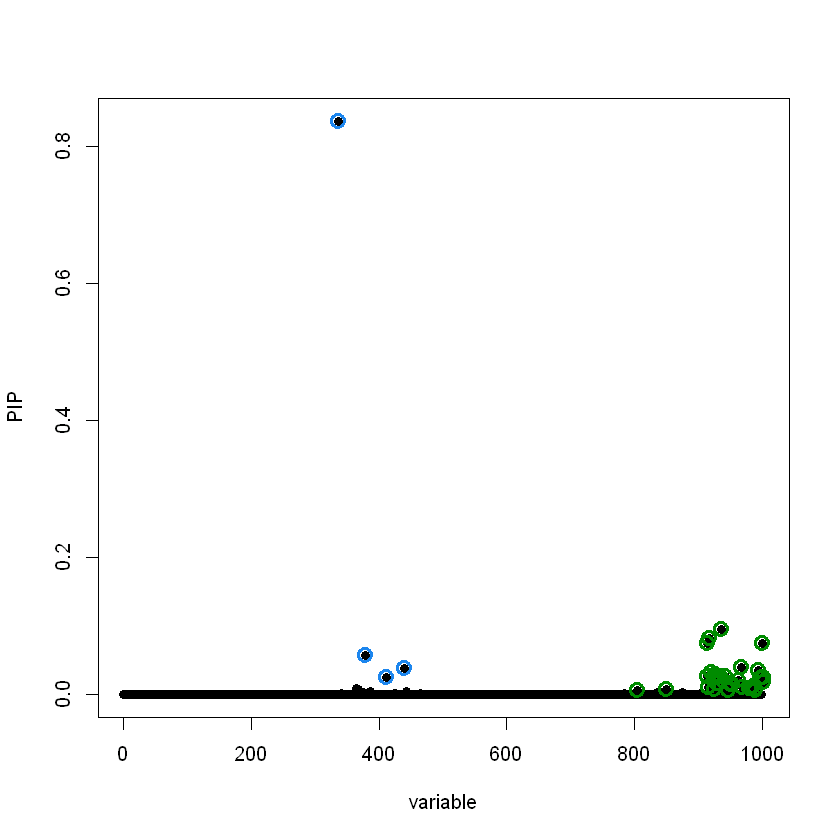

In [191]:
susie_plot(n3_rss, y="PIP")

-------------------------------------------

In [31]:
sessionInfo()

R version 4.1.2 (2021-11-01)
Platform: x86_64-w64-mingw32/x64 (64-bit)
Running under: Windows 10 x64 (build 19045)

Matrix products: default

locale:
[1] LC_COLLATE=English_United States.1252 
[2] LC_CTYPE=English_United States.1252   
[3] LC_MONETARY=English_United States.1252
[4] LC_NUMERIC=C                          
[5] LC_TIME=English_United States.1252    

attached base packages:
[1] stats     graphics  grDevices utils     datasets  methods   base     

other attached packages:
[1] corrplot_0.95  susieR_0.12.35

loaded via a namespace (and not attached):
 [1] Rcpp_1.0.10        plyr_1.8.8         pillar_1.10.1      compiler_4.1.2    
 [5] base64enc_0.1-3    tools_4.1.2        digest_0.6.37      uuid_1.1-0        
 [9] jsonlite_1.8.4     evaluate_1.0.3     lifecycle_1.0.4    tibble_3.2.1      
[13] gtable_0.3.6       lattice_0.22-6     pkgconfig_2.0.3    rlang_1.1.0       
[17] Matrix_1.6-5       IRdisplay_1.1      cli_3.6.3          IRkernel_1.3.2    
[21] fastmap_1.2.0      rep